In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Decision Trees -->  Random Forest --> Bagging/Boosting

--> When the data is highly cateregorical


--> We can't use one hot encoding, target encoding(why? )


--> Revise target, binary and one hot encoding

--> Problem Statement:

--> A number of people are leaving the company , find the reason why with the data provided

--> Let's say age and overtime are the only features we have and we want to predict if a person will leave or not.

The decision tree looks something like:


if age < 29:

    if overtime > 2.5:

        leave = True

    else:

        leave = False 

else:

    if age > 35:

        leave = False

    else:

        leave = True

--> important step is to chose the root node , whether to start with age or overtime , we need not write the if -else loops, Data science will take care of that 

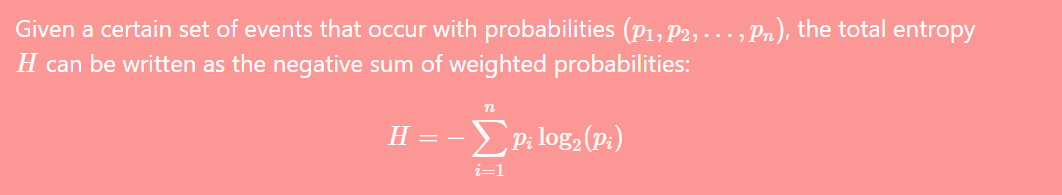

--> Take a node, compute entropy

--> entropy should be low 


At each node entropy is calculated and the weightied entropy of it's children is also calculated, that weighted entropy should also be low  

The idea is to subtract from the entropy of our data before the split the entropy of each possible partition thereafter. We then select the split that yields the largest reduction in entropy, or equivalently, the largest increase in information.

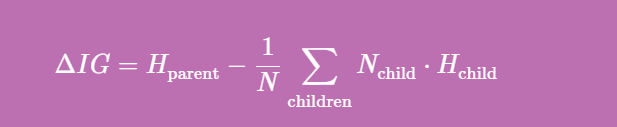

Information gain  = Parent Entropy - Weighted Child Entropy

The more the information gain, the better the split.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

In [3]:
df = pd.read_csv("HR-Employee-Attrition.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
with open('preprocessed_X_sm.pickle', 'rb') as handle:
    # X_train = pickle.load(handle)
    X_train = pd.read_pickle("preprocessed_X_sm.pickle")

with open('X_test.pickle', 'rb') as handle:
    # X_test = pickle.load(handle)
    X_test = pd.read_pickle("X_test.pickle")


with open('y_sm.pickle', 'rb') as handle:
    # y_train = pickle.load(handle)
    y_train = pd.read_pickle("y_sm.pickle")


with open('y_test.pickle', 'rb') as handle:
    # y_test = pickle.load(handle)
    y_test = pd.read_pickle("y_test.pickle")

In [5]:
X_train.shape

(1848, 36)

In [6]:
from sklearn.tree import DecisionTreeClassifier



In [7]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
model.score(X_test, y_test)

0.7744565217391305

Model is trained by calculating entropy at each node, but he problem is log is computationally expensive. So instead gini impurity is used

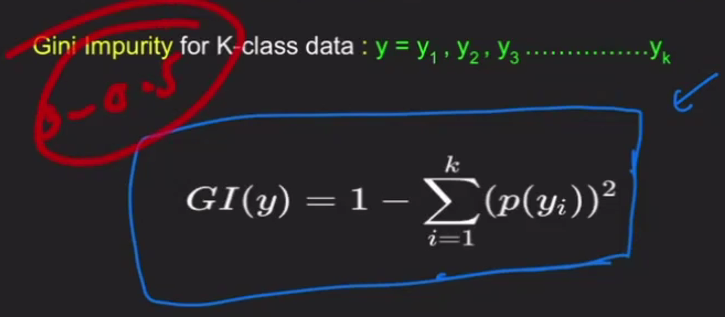

Range of gini impurity is [0, 0.5]

In [9]:
import numpy as np

def entropy(y):
    zero_count = 0
    one_count = 0
    for label in y:
        if label == 0:
            zero_count += 1
        else:
            one_count += 1
    p0 = zero_count / len(y)
    p1 = one_count / len(y)
    if(p0 == 0 or p1 == 0):
        return 0
    entropy =  p0 * np.log2(p0) + p1 * np.log2(p1)
    return -entropy


In [10]:

def information_gain(parent, left_child, right_child):
    
    '''
    Compute information gain given left_child target variables (list), right_child target variables(list) and their parent targets(list)
    '''
    parent_entropy = entropy(parent)
    left_child_entropy = entropy(left_child)
    right_child_entropy = entropy(right_child)
    left_child_weight = len(left_child) / len(parent)
    right_child_weight = len(right_child) / len(parent)
    info_gain = parent_entropy - (left_child_weight * left_child_entropy + right_child_weight * right_child_entropy)
    return info_gain

In [11]:
def best_split(features,labels):
    best_threshold = None
    best_info_gain = -np.inf
    for threshold in np.unique(features):
        y_left = labels[features <= threshold] #list of labels in left child
        y_right = labels[features > threshold]  #list of labels in right child
        
        if len(y_left) > 0 and len(y_right) > 0:
            gain = information_gain(labels, y_left, y_right)                 # Caclulate the information gain and save the split parameters if the current split if better then the previous best

            if gain > best_info_gain:
                best_threshold = threshold
                best_info_gain = gain
    
    return best_threshold


In [12]:

features = np.array([0.41, 0.3, 0.74, 0.27, 0.39, 0.53, 0.23, 0.36, 0.15, 0.9])
labels = np.array([0,1,0,0,1,1,1,0,1,0])

best_threshold = best_split(features, labels)
print(best_threshold)



0.23


In [13]:
def entropy(labels):
    entropy = 0
    counts = np.bincount(labels)
    probabilities = counts / len(labels)
    for p in probabilities:
        entropy += p * np.log2(p)
    
    return np.round(-entropy, 2)


In [14]:
labels = [0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0]
entropy(labels)

np.float64(0.99)

In [15]:
X_train = [[4, 13, 2], [9, 8, 11], [14, 4, 2]]  
y_train = [0,1,0] 
X_train = np.asarray(X_train)
y_train = np.asarray(y_train)
observation = [[5,15,25]]
observation = np.asarray(observation)
from sklearn.tree import DecisionTreeClassifier

#INITIALIZE DECISION TREE CLASSIFICATION MODEL
classifier = DecisionTreeClassifier()

#TRAIN DECISION TREE CLASSIFICATION MODEL
classifier.fit(X_train, y_train)

print(classifier.predict(observation))

[1]


In [17]:

Attribute1 = np.array([1,1,1,1,1,0,0,0,1,1])
Attribute2 = np.array([0,1,1,0,1,0,0,0,1,0])
Class = np.array([0,0,0,1,0,1,1,1,1,1])

print(entropy(Class))

0.97


In [ ]:
def entropy(labels):
    entropy = 0
    counts = np.bincount(labels.astype(int))
    probabilities = counts / len(labels)
    for p in probabilities:
        if p != 0:
            entropy += p * np.log2(p)
    
    return np.round(-entropy, 2)

Attribute1 = np.array([1,1,1,1,1,0,0,0,1,1])
Attribute2 = np.array([0,1,1,0,1,0,0,0,1,0])
Class = np.array([0,0,0,1,0,1,1,1,1,1])

print(entropy(Class))


0.97
[0. 0. 0. 1. 0. 1. 1.] [1. 1. 1.]
0.99
-0.0
0.277


In [33]:
def Split_gain(features, Class):
    attr_child_1 = []
    attr_child_2 = []
    for i in range(len(Class)):
        if features[i] == 1:
            attr_child_1 = np.append(attr_child_1, Class[i])
        else:
            attr_child_2 = np.append(attr_child_2, Class[i])

    attr_child_1 = np.asarray(attr_child_1)
    attr_child_2 = np.asarray(attr_child_2)
    # print(attr_child_1, attr_child_2)

    # print(entropy(attr_child_1))
    # print(entropy(attr_child_2))
    IG = entropy(Class) - (len(attr_child_1)/len(Class)*entropy(attr_child_1) + len(attr_child_2)/len(Class)*entropy(attr_child_2))
    return np.round(IG, 2)

In [34]:
print(Split_gain(Attribute1, Class))
print(Split_gain(Attribute2, Class))

0.28
0.26


In [35]:
Class = np.array([0,0,0,1,0,1,1,1,1,1])

counts = np.bincount(Class)
print(counts)

[4 6]
